<a href="https://colab.research.google.com/github/cemilkaracam/Haar-Wavelet-Regularized-Approximation-of-Discontinuous-Functions/blob/main/Comparative_Visualization_of_Unified_and_Decomposition_Strategies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

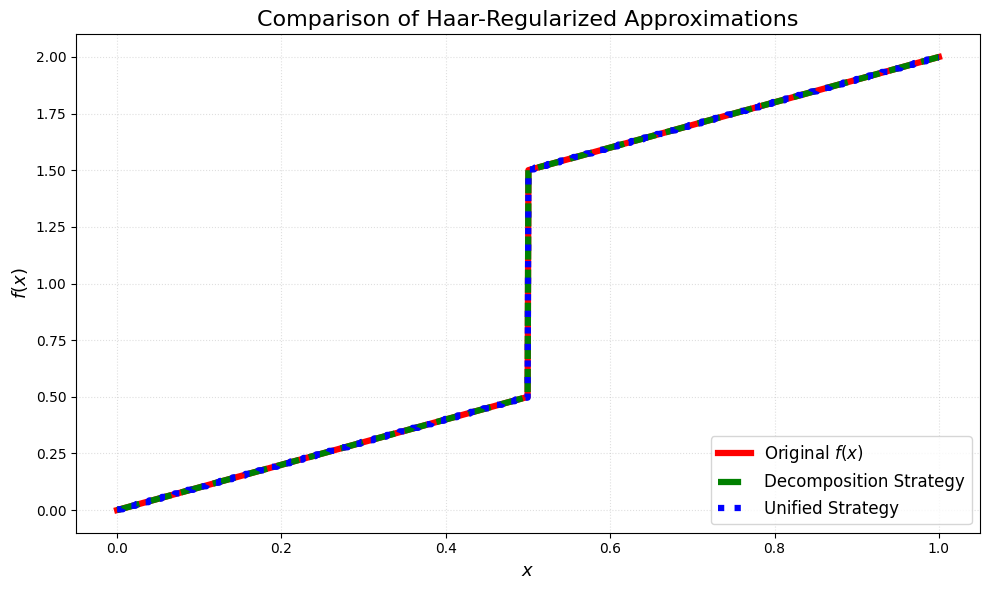

In [ ]:
# Haar Regularization Strategy Comparison: Unified vs Decomposition

# 1. Gerekli kütüphane kurulumu (Colab için)
!pip install PyWavelets --quiet

# 2. Kütüphaneleri içe aktar
import numpy as np
import matplotlib.pyplot as plt
import pywt

# 3. Smooth ve kesikli bileşenler
def f_c(x):
    return x

def f_d(x):
    return (x >= 0.5).astype(float)

def f_full(x):
    return f_c(x) + f_d(x)

# 4. Haar regularizasyon fonksiyonu (sadece scaling coefficients tutulur)
def haar_regularize(fx, level=3):
    coeffs = pywt.wavedec(fx, 'haar', level=level)
    coeffs_trunc = [coeffs[0]] + [np.zeros_like(c) for c in coeffs[1:]]
    return pywt.waverec(coeffs_trunc, 'haar')[:len(fx)]

# 5. Domain ve yaklaştırmalar
x = np.linspace(0, 1, 1024)
f_orig = f_full(x)
f_decomp = f_c(x) + haar_regularize(f_d(x), level=3)
f_unified = haar_regularize(f_orig, level=3)

# 6. Görselleştirme
plt.figure(figsize=(10, 6))
plt.plot(x, f_orig, 'r-', linewidth=4.5, label='Original $f(x)$')
plt.plot(x, f_decomp, 'g--', linewidth=4.5, label='Decomposition Strategy')
plt.plot(x, f_unified, 'b:', linewidth=4.5, label='Unified Strategy')
plt.title('Comparison of Haar-Regularized Approximations', fontsize=16)
plt.xlabel('$x$', fontsize=13)
plt.ylabel('$f(x)$', fontsize=13)
plt.legend(fontsize=12, loc='lower right')
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

